# Домашнее задание 5. Генеративные модели


В этом ноутбуке мы будем работать с одной и той же задачей (генерация и реконструкция изображений),
сравнивая поведение классического автоэнкодера и вариационного автоэнкодера.

Домашнее задание опирается на материалы по автоэнкодерам, вариационным автоэнкодерам и латентным
переменным, а также продолжает линию лекции по генеративным моделям.

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Во всех задачах мы работаем с одной и той же постановкой: учимся сжимать и восстанавливать изображения,
а затем сравниваем свойства AE и VAE.


## Теоретическая часть

### Автоэнкодер (AE)

Автоэнкодер — это нейросеть, которая принимает на вход объект (например, изображение),
сжимает его в латентный вектор фиксированной размерности, а затем восстанавливает обратно.

Состоит из двух частей:

- **Энкодер** отображает входной вектор в латентное представление меньшей размерности.
- **Декодер** восстанавливает объект из латентного вектора.

Модель обучается минимизировать ошибку реконструкции (насколько сильно восстановленное изображение
отличается от исходного). Это делает автоэнкодер хорошим инструментом для сжатия, денойзинга
и выделения признаков, но он не задает явную вероятностную модель данных.

### Вариационный автоэнкодер (VAE)

Вариационный автоэнкодер накладывает на латентное пространство вероятностную структуру.
Вместо одного латентного вектора для каждого объекта он учит распределение в латентном пространстве
(обычно многомерное нормальное с параметрами среднее и дисперсия).

Обучение осуществляется по нижней оценке правдоподобия (ELBO), которая одновременно:

- поощряет хорошую реконструкцию объектов;
- прижимает распределение скрытых переменных к простому априорному распределению.

Благодаря этому VAE умеет как реконструировать данные, так и генерировать новые правдоподобные
примеры, отбирая точки напрямую из латентного распределения.

### Наша экспериментальная схема

В этом домашнем задании:

- мы используем один и тот же датасет изображений;
- обучаем на нем простой автоэнкодер;
- обучаем на нем вариационный автоэнкодер с той же архитектурой энкодера и декодера;
- сравниваем качество реконструкции, структуру латентного пространства и сгенерированные семплы.

Логика: Теория → Гипотеза → Эксперимент → Интерпретация.

После решения каждой задачи не забудьте заполнить поле «Интерпретация».


## Настройка окружения

In [1]:
# Импорты
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксация генераторов случайных чисел
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")


Используемое устройство: cpu


## Подготовка данных

В качестве базовой задачи будем использовать простой датасет изображений цифр (MNIST).

Что сделаем:

- загрузим обучающую и тестовую выборки;
- нормализуем изображения в диапазон от 0 до 1;
- подготовим функции визуализации батча и реконструкций.


In [2]:
# Загрузка датасета MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")


Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [3]:
# Вспомогательная функция для визуализации батча изображений

def show_images(images, title="Примеры изображений", nrow=8):
    images = images.detach().cpu()
    grid = torch.clone(images[: nrow * nrow])
    fig, ax = plt.subplots(figsize=(nrow, nrow))
    grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()


In [4]:
import torchvision  # импортируем здесь для функций визуализации

---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

Эти задачи направлены на базовое понимание того, как выглядят данные,
как устроен автоэнкодер и как оценивать его реконструкции.


## Задача 1. Загрузка и визуализация данных

### Постановка задачи

Загрузить обучающую выборку изображений цифр, посмотреть на форму тензоров
и визуализировать несколько примеров.

### Теоретический минимум

- Каждый объект представлен как изображение 28×28 пикселей в оттенках серого.
- Для подачи в полносвязную сеть изображения часто разворачивают в вектор длины 784.
- Важно убедиться, что данные нормализованы и имеют ожидаемую форму.


Форма батча изображений: torch.Size([128, 1, 28, 28])
Форма батча меток: torch.Size([128])


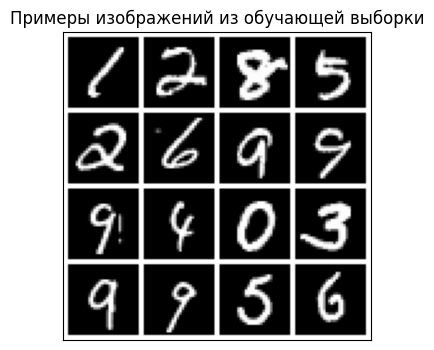

In [5]:
# Задача 1. Загрузка и визуализация данных

# Получите один батч из train_loader
images, labels = next(iter(train_loader))

# TODO: Выведите форму батча
print("Форма батча изображений:", images.shape)
print("Форма батча меток:", labels.shape)

# TODO: Визуализируйте 16 примеров с помощью show_images()
show_images(images, title="Примеры изображений из обучающей выборки", nrow=4)

**Интерпретация:**
* Батчи содержат изображения с разрешением 28х28 пикселей. Каждому изображению соответствует одна метка.  
* Из примеров изображений видно, что одна и та же цифра может изображаться поразному - характеризоваться различными областями с высокой интенсивностью пикселей.

## Задача 2. Реализация и обучение простого автоэнкодера

### Постановка задачи

Реализовать простой полносвязный автоэнкодер для изображений цифр:

- энкодер: несколько линейных слоев, сжимающих изображение в латентный вектор фиксированной размерности;
- декодер: несколько линейных слоев, восстанавливающих изображение из латентного вектора.

Обучить автоэнкодер на обучающей выборке и визуально оценить качество реконструкций.

### Теоретический минимум

- Автоэнкодер минимизирует ошибку реконструкции (MSE или бинарную кросс-энтропию).
- Латентное пространство может иметь гораздо меньшую размерность, чем исходное изображение.
- Качественный автоэнкодер должен уметь восстанавливать основные структуры (контуры цифр).


Эпоха 1/5,  loss = 0.0510
Эпоха 2/5,  loss = 0.0243
Эпоха 3/5,  loss = 0.0186
Эпоха 4/5,  loss = 0.0154
Эпоха 5/5,  loss = 0.0133


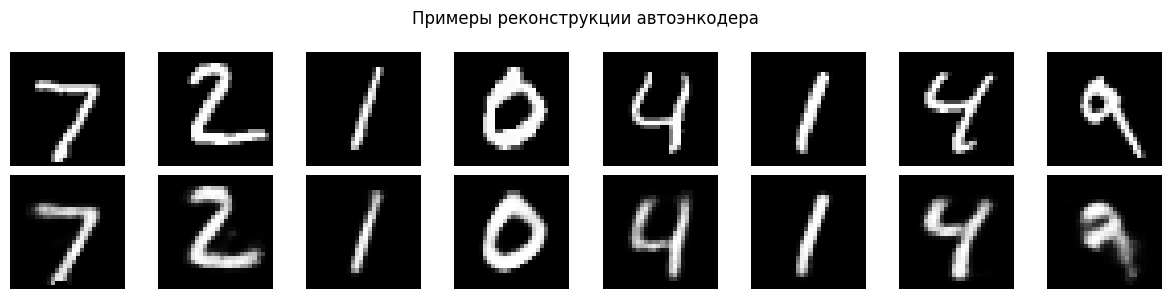

In [6]:
# Задача 2. Реализация и обучение простого автоэнкодера

class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # TODO: Определите encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # TODO: Определите decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),
            # Замена размерности второй оси (784) на (1, 28, 28)
            nn.Unflatten(1, (1, 28, 28))
        )

    # Для задания 9
    def decode(self, z):
            return self.decoder(z)

    def forward(self, x):
        # TODO: Forward pass
        z = self.encoder(x)
        x_recon = self.decoder(z)
        assert x_recon.dim() == x.dim() # Проверка сохранения формы
        return x_recon

# TODO: Создайте модель
model = SimpleAutoencoder(latent_dim=32)

# TODO: Определите loss и optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Обучите модель
train_losses = []
epochs = 5
for epoch in range(1, epochs+1):
    model.train()
    accum_loss = 0.0
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        mod_res = model(images)
        loss = criterion(mod_res, images)
        loss.backward()
        optimizer.step()
        # Потери в расчёте на батч
        accum_loss += loss.item() * images.size(0)
    epoch_loss = accum_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f'Эпоха {epoch}/{epochs},  loss = {epoch_loss:.4f}')

# Визуализация по test_loader
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(DEVICE)
    input_img = images[:8]
    mod_res = model(input_img)

input_img_np = input_img.cpu().numpy()
mod_res_np = mod_res.cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    ax = axes[0, i]
    ax.imshow(input_img_np[i].squeeze(), cmap='gray')
    ax.axis('off')

for i in range(8):
    ax = axes[1, i]
    ax.imshow(mod_res_np[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('Примеры реконструкции автоэнкодера')
plt.tight_layout()
plt.show()

**Интерпретация:**  
Реконструированные изображения хорошо сохраняют контуры исходных цифр. Реконструированные цифры более бледные из-за потери части информации при сжатии в латентное пространство.

## Задача 3. Анализ динамики ошибки автоэнкодера

### Постановка задачи

Построить график ошибки реконструкции автоэнкодера по эпохам обучения
и проинтерпретировать его.

### Теоретический минимум

- Убывание ошибки по эпохам говорит о том, что модель успешно обучается.
- Плато или рост ошибки могут сигнализировать о переобучении или проблемах с оптимизацией.


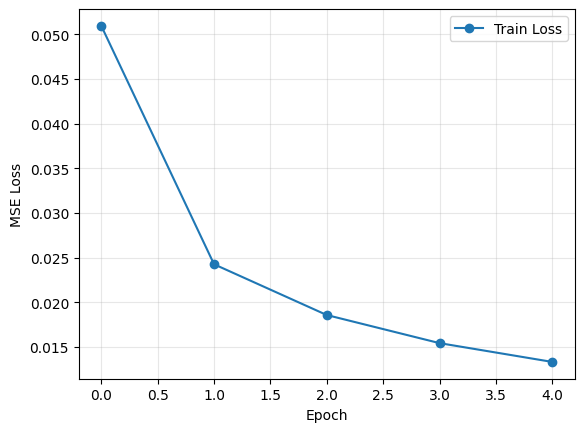

In [7]:
# Задача 3. Анализ динамики ошибки автоэнкодера

# TODO: Постройте график ошибки по эпохам
plt.plot(train_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# TODO: Проанализируйте график

**Интерпретация:**
* График показывает быстрое обучения модели - интенсивное снижение метрики MSE произошло за первые 3 эпохи (с 0,05 до 0,018).
* График гладкий, что указывает на стабильность процесса обучения.
* Поскольку график построен только для Train Loss, то по нему нельзя сделать однозначный вывод о приросте обобщающей способности модели. Однако, ранее было выявлено визуально, что 5 эпох обучения достаточно для качественной реконструкции изображений.

## Задача 4. Визуализация латентного пространства автоэнкодера

### Постановка задачи

Обучить вариант автоэнкодера с двумерным латентным пространством и
визуализировать распределение латентных векторов для тестовой выборки,
окрашивая точки по истинным классам цифр.

### Теоретический минимум

- Двумерное латентное пространство удобно для визуализации.
- Кластеры в латентном пространстве могут соответствовать разным классам данных.


[2D AE] Эпоха 1/10,  loss = 0.0596
[2D AE] Эпоха 2/10,  loss = 0.0466
[2D AE] Эпоха 3/10,  loss = 0.0437
[2D AE] Эпоха 4/10,  loss = 0.0421
[2D AE] Эпоха 5/10,  loss = 0.0411
[2D AE] Эпоха 6/10,  loss = 0.0403
[2D AE] Эпоха 7/10,  loss = 0.0397
[2D AE] Эпоха 8/10,  loss = 0.0392
[2D AE] Эпоха 9/10,  loss = 0.0388
[2D AE] Эпоха 10/10,  loss = 0.0383


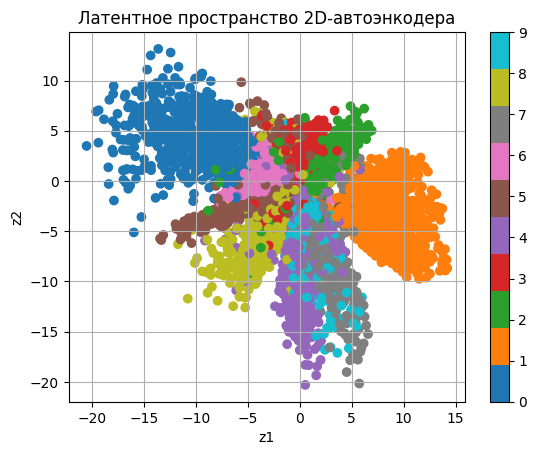

In [8]:
# Задача 4. Визуализация латентного пространства автоэнкодера

# TODO: Обучите модель с latent_dim=2

class AutoencoderLatent2D(SimpleAutoencoder):
    def __init__(self, latent_dim=2):
        super().__init__()
        # TODO: Определите encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # TODO: Определите decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),
            # Замена размерности второй оси (784) на (1, 28, 28)
            nn.Unflatten(1, (1, 28, 28))
        )

    def encode_res(self, x):
        """
        Возвращает латентное представление
        """
        return self.encoder(x)

ae_2d = AutoencoderLatent2D(latent_dim=2).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_2d.parameters(), lr=1e-3)

epochs = 10
for epoch in range(1, epochs+1):
    ae_2d.train()
    accum_loss = 0.0
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        mod_res = ae_2d(images)
        loss = criterion(mod_res, images)
        loss.backward()
        optimizer.step()
        # Потери в расчёте на батч
        accum_loss += loss.item() * images.size(0)
    epoch_loss = accum_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f'[2D AE] Эпоха {epoch}/{epochs},  loss = {epoch_loss:.4f}')

# TODO: Получите латентные представления для test_dataset
ae_2d.eval()
latents = []
labels_list = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        z = ae_2d.encode_res(images)
        latents.append(z.cpu())
        labels_list.append(labels)
latents = torch.cat(latents, dim=0)
labels = torch.cat(labels_list, dim=0)
latents_np = latents.numpy()
labels_np  = labels.numpy()

# TODO: Визуализируйте scatter plot
plt.scatter(latents_np[:, 0], latents_np[:, 1], c=labels_np, cmap='tab10')
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('Латентное пространство 2D-автоэнкодера')
plt.colorbar()
plt.grid(True)
plt.show()

**Интерпретация:**
* Из диаграммы следует, что изображения не со всеми цифрами разделяются в латентном пространстве одинаково качественно. Например, хорошо выделяются изображения с цифрами: 0, 1, 2, 3, 6, 8.
* С другой стороны, плохо разделяются изображения с цифрами, которые могут иметь похожее изображени: 4, 7, 9.
* Очень плохо выделяются изображения с цифрой 5.
* Видно, что в латентном пространстве остаются большие невостребованные (пустые) области. Попытки генерации изображений по координатам латентного пространства из этих областей будут приводить к получению нежелательных артефактов.

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

В этих задачах мы реализуем вариационный автоэнкодер и сравним его с обычным AE
по реконструкции и поведению в латентном пространстве.

## Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

### Постановка задачи

Реализовать вариационный автоэнкодер со схожей архитектурой энкодера и декодера,
как у автоэнкодера, и обучить его на тех же данных.

### Теоретический минимум

- Энкодер VAE предсказывает среднее и разброс распределения в латентном пространстве.
- В латентном слое мы семплируем случайный вектор на основе этих параметров.
- Функция потерь VAE сочетает ошибку реконструкции и регуляризацию латентного пространства.


[VAE] Эпоха 1/5,  total=51.7327,  rec=49.4913,  kl=2.2415
[VAE] Эпоха 2/5,  total=39.6109,  rec=33.5201,  kl=6.0909
[VAE] Эпоха 3/5,  total=35.1889,  rec=27.5359,  kl=7.6530
[VAE] Эпоха 4/5,  total=33.1745,  rec=24.9079,  kl=8.2666
[VAE] Эпоха 5/5,  total=32.2245,  rec=23.6424,  kl=8.5821


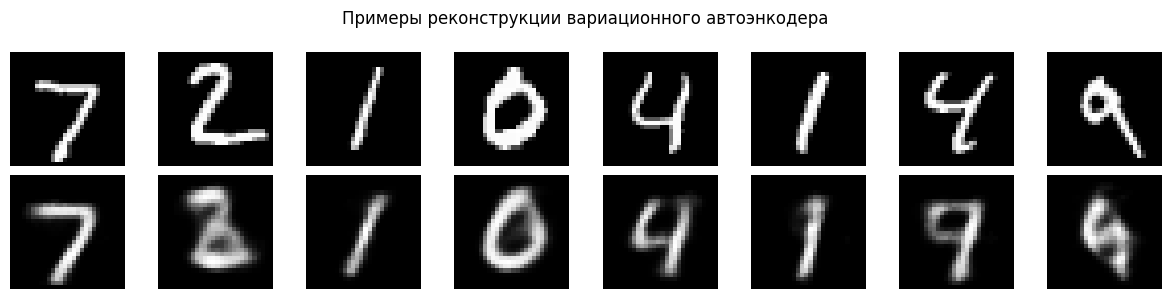

In [9]:
# Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # TODO: Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        # TODO: Mu и logvar слои
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # TODO: Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def encode(self, x):
        # TODO: Получите mu и logvar
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # TODO: Трюк репараметризации
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    # Для задания 7
    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        # TODO: Full forward pass
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

# TODO: Создайте и обучите VAE
vae = VAE(latent_dim=32)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# TODO: Используйте ELBO loss:
epochs = 5
for epoch in range(1, epochs + 1):
    vae.train()
    accum_total = 0.0
    accum_rec = 0.0
    accum_kl = 0.0
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, logvar = vae(images)

        reconstruction_loss = F.mse_loss(recon, images, reduction='sum') # reduction='sum' - чтобы масштаб соответствовал kl_loss
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconstruction_loss + kl_loss
        loss.backward()
        optimizer.step()

        accum_total += loss.item()
        accum_rec += reconstruction_loss.item()
        accum_kl += kl_loss.item()

    epoch_total = accum_total / len(train_loader.dataset)
    epoch_rec = accum_rec / len(train_loader.dataset)
    epoch_kl = accum_kl / len(train_loader.dataset)
    print(f'[VAE] Эпоха {epoch}/{epochs},  total={epoch_total:.4f},  rec={epoch_rec:.4f},  kl={epoch_kl:.4f}')


# Визуализация по test_loader
vae.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(DEVICE)
    input_img = images[:8]
    mod_res, _, _ = vae(input_img)

input_img_np = input_img.cpu().numpy()
mod_res_np = mod_res.cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    ax = axes[0, i]
    ax.imshow(input_img_np[i].squeeze(), cmap='gray')
    ax.axis('off')

for i in range(8):
    ax = axes[1, i]
    ax.imshow(mod_res_np[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('Примеры реконструкции вариационного автоэнкодера')
plt.tight_layout()
plt.show()

**Интерпретация:**
* Реконструкции, обеспечиваемые VAE более размыты. Иногда вплоть до потери визуальной различимости цифр (например, 4 и 9).
* Размытость является следствием вероятностых свойств латентного слоя VAE. Вероятностные свойства повышают пригодность VAE для генерации новых изображений.

## Задача 6. Сравнение реконструкций AE и VAE на одних и тех же примерах

### Постановка задачи

Построить визуальное сравнение реконструкций автоэнкодера и вариационного автоэнкодера
на одних и тех же изображениях.

### Теоретический минимум

- AE стремится максимально точно копировать вход.
- VAE может жертвовать точностью ради более гладкого латентного пространства.


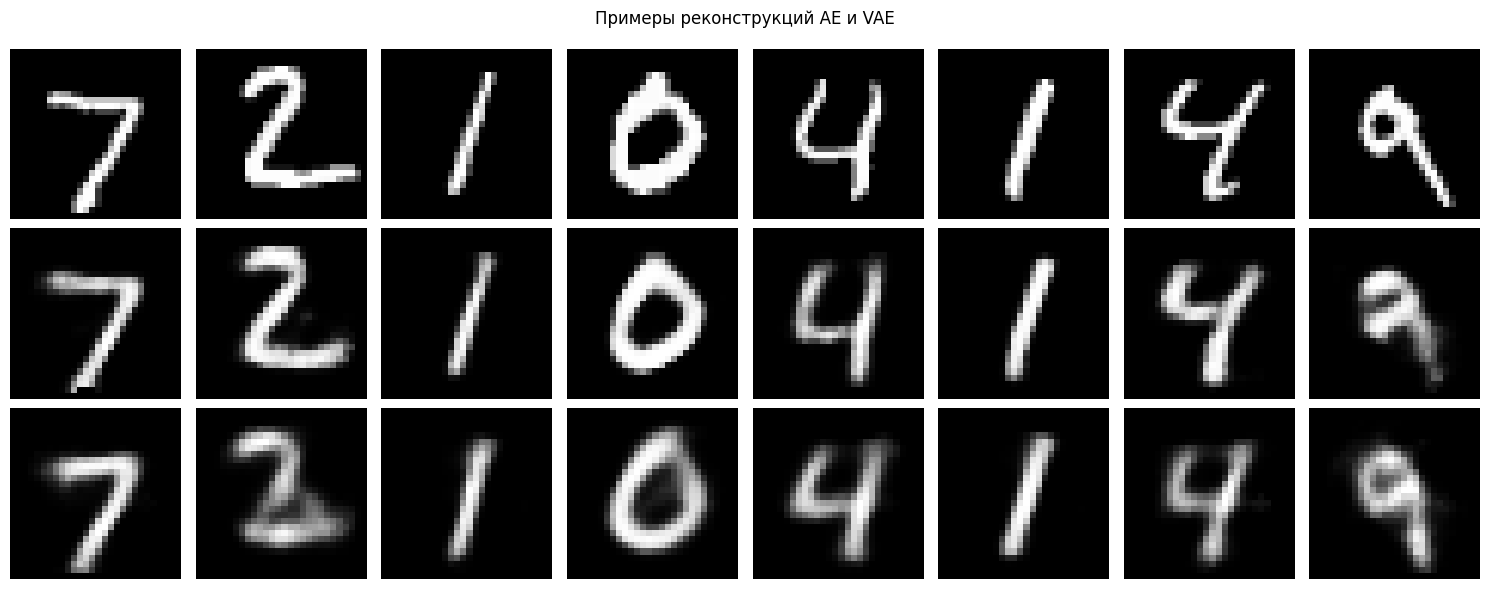

In [10]:
# Задача 6. Сравнение реконструкций AE и VAE

# TODO: Получите реконструкции из обеих моделей
model.eval()
vae.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(DEVICE)
    input_img = images[:8].to(DEVICE)
    ae_recon = model(input_img)
    vae_recon, _, _ = vae(input_img)

input_img_np = input_img.cpu().numpy()
ae_recon_np = ae_recon.cpu().numpy()
vae_recon_np = vae_recon.cpu().numpy()

# TODO: Визуализируйте сравнение
fig, axes = plt.subplots(3, 8, figsize=(15, 6))
# Строка 1: Оригиналы
for i in range(8):
    ax = axes[0, i]
    ax.imshow(input_img_np[i].squeeze(), cmap='gray')
    ax.axis('off')

# Строка 2: AE реконструкции
for i in range(8):
    ax = axes[1, i]
    ax.imshow(ae_recon_np[i].squeeze(), cmap='gray')
    ax.axis('off')

# Строка 3: VAE реконструкции
for i in range(8):
    ax = axes[2, i]
    ax.imshow(vae_recon_np[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('Примеры реконструкций AE и VAE')
plt.tight_layout()
plt.show()


**Интерпретация:**
* Из сравнения результатов AE и VAE видно, что AE чаще даёт более резкие изображения.
* VAE иногда может генерировать "промежуточные" варианты, например, как для цифр 2 и 4. Это указывает на более высокие генеративные возможности VAE.

## Задача 7. Интерполяция в латентном пространстве VAE

### Постановка задачи

Взять два разных изображения из тестовой выборки, получить их латентные коды в VAE
и построить интерполяцию между ними. Визуализировать, как плавно меняется картинка
при движении по отрезку в латентном пространстве.

### Теоретический минимум

- В хорошо устроенном латентном пространстве небольшие изменения латентного кода
  приводят к плавным и осмысленным изменениям сгенерированного объекта.


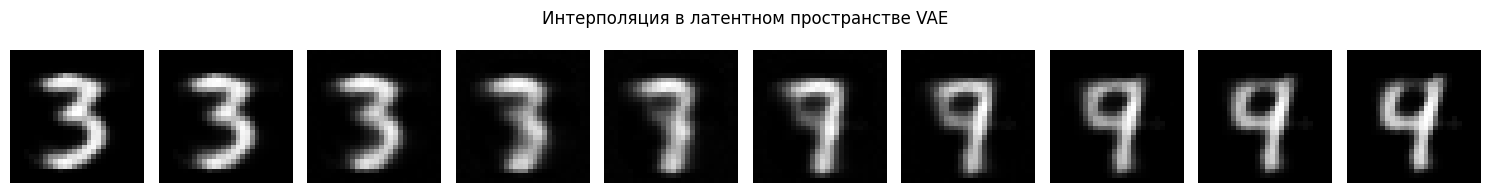

In [11]:
# Задача 7. Интерполяция в латентном пространстве VAE

# TODO: Возьмите два изображения
idx1, idx2 = 30, 42
img1, img2 = test_dataset[idx1][0], test_dataset[idx2][0]

# TODO: Получите их латентные коды
vae.eval()
with torch.no_grad():
    mu1, _ = vae.encode(img1.view(1, -1))
    mu2, _ = vae.encode(img2.view(1, -1))

    # TODO: Интерполируйте
    images = []
    alphas = torch.linspace(0, 1, steps=10)
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        x_interp = vae.decode(z_interp)
        x_interp_np = x_interp.cpu().numpy()
        images.append(x_interp_np)

# визуализируйте
fig, axes = plt.subplots(1, 10, figsize=(15, 6))
for i in range(10):
    ax = axes[i]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Интерполяция в латентном пространстве VAE', y=0.65)
plt.tight_layout()
plt.show()


**Интерпретация:**
* Между первым и последним изображением в ряду наблюдаются плавные изменения. Это указывает на то, что латентное пространство VAE хорошо отражает структуру данных.
* Если крайние цифры далеки друг от друга в латентном пространстве, то при переходе от одного края к другому могут отображаться соседние (по латентному пространству) цифры.

---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь нас интересуют генерация новых примеров и более формальное сравнение
качества автоэнкодера и вариационного автоэнкодера.

## Задача 8. Генерация новых примеров из латентного пространства

### Постановка задачи

Сгенерировать набор новых изображений, не встречавшихся в обучающей выборке,
используя:

- выборку латентных векторов из простого распределения;
- декодер VAE для получения изображений.

Сравнить разнообразие и правдоподобие полученных картинок.

### Теоретический минимум

- В VAE латентное пространство подгоняется под стандартное нормальное распределение.
- Это позволяет генерировать новые данные, просто выбирая случайные точки в латентном пространстве.


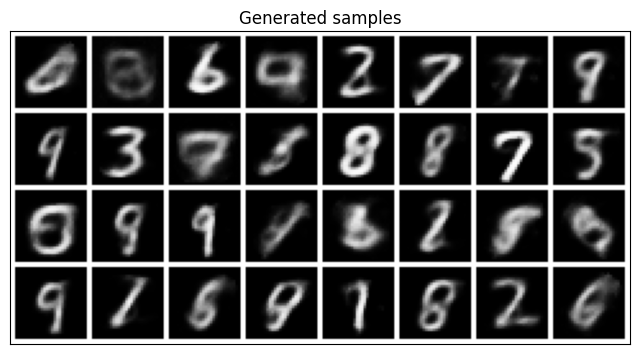

In [12]:
# Задача 8. Генерация новых примеров из латентного пространства

# TODO: Сгенерируйте случайные z из N(0, I)
latent_dim=32
g = torch.Generator().manual_seed(42) # иначе seed не передавался
z_samples = torch.randn(32, latent_dim, device=DEVICE, generator=g)

# TODO: Декодируйте
vae.eval()
with torch.no_grad():
    generated = vae.decode(z_samples)

# TODO: Визуализируйте
show_images(generated.view(-1, 1, 28, 28), title="Generated samples")

**Интерпретация:**
* Обращение к случайным областям латентного пространства VAE всегда позволяет получить некоторый результат, что указывает на его высокие генеративные качества.
* Генеративные качества модели всегда обеспечивают новые изображения, но эти изображения не всегда правдоподобны.

## Задача 9. Количественное сравнение AE и VAE

### Постановка задачи

Сравнить автоэнкодер и вариационный автоэнкодер по двум простым метрикам:

1. Средняя ошибка реконструкции на тестовой выборке.
2. Простая оценка разнообразия сгенерированных примеров.

### Теоретический минимум

- Ошибка реконструкции показывает, насколько модель хорошо запоминает и восстанавливает обучающую выборку.
- Разнообразие семплов показывает, насколько модель способна порождать много разных примеров.


In [13]:
# Задача 9. Количественное сравнение AE и VAE

# TODO: 1. Средняя ошибка реконструкции
model.eval()
vae.eval()

sum_loss_ae = 0.0
sum_loss_vae = 0.0
pix_cnt = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        pix_cnt  += images.numel()

        # Для AE
        mod_res = model(images)
        loss_ae = F.mse_loss(mod_res, images, reduction='sum')
        sum_loss_ae += loss_ae.item()

        # Для VAE
        mod_res, _, _ = vae(images)
        loss_vae = F.mse_loss(mod_res, images, reduction='sum')
        sum_loss_vae += loss_vae.item()

ae_mse = sum_loss_ae / pix_cnt
vae_mse = sum_loss_vae / pix_cnt
print(f"AE MSE: {ae_mse:.4f}")
print(f"VAE MSE: {vae_mse:.4f}")

# TODO: 2. Оценка разнообразия
# Сгенерируйте 100 сэмплов из каждой модели
# Вычислите среднее попарное расстояние

def mean_pairwise_dist(samples, pairs=500):
    """
    Расчитывает среднюю попарную L2-дистанцию
    """
    rows = samples.shape[0]
    first_idx = np.random.randint(0, rows, size=pairs)
    second_idx = np.random.randint(0, rows, size=pairs)
    pair_diffs = samples[first_idx] - samples[second_idx]
    pair_dists = np.linalg.norm(pair_diffs, axis=1)
    return pair_dists.mean()

with torch.no_grad():
    z = torch.randn(100, latent_dim).to(DEVICE)
    ae_samples = model.decode(z).cpu().numpy().reshape(100, -1)
    vae_samples = vae.decode(z).cpu().numpy().reshape(100, -1)

diversity_ae = mean_pairwise_dist(ae_samples)
diversity_vae = mean_pairwise_dist(vae_samples)
print(f"AE diversity: {diversity_ae:.4f}")
print(f"VAE diversity: {diversity_vae:.4f}")

AE MSE: 0.0122
VAE MSE: 0.0289
AE diversity: 3.7449
VAE diversity: 7.1906


**Интерпретация:**
* Вариационный автоэнкодер показывает большую ошибку реконструкции из-за применения стахостического подхода к генерации изображений, в то время как у обычного автоэнкодера генерирация детерменированная.  
* С другой стороны, благодаря вероятностным свойствам VAE, генерируемые им изображения более разнообразны, на что указывает большая величина средней попарной дистанции (diversity).

---

## Интерпретация результатов

В ходе домашнего задания мы увидели следующее:

- Обычный автоэнкодер хорошо восстанавливает входные изображения и дает низкую ошибку реконструкции,
  но его латентное пространство не имеет явной вероятностной структуры.
- Вариационный автоэнкодер вводит вероятностное латентное пространство и использует ELBO,
  чтобы одновременно учиться восстанавливать данные и упорядочивать скрытые представления.
- В визуальных сравнениях автоэнкодер дает более резкие реконструкции, тогда как VAE иногда сглаживает детали,
  но зато позволяет лучше интерполировать между объектами и легко генерировать новые примеры.
- Латентное пространство VAE оказывается более регулярным: интерполяции между точками выглядят плавно и осмысленно.
- При генерации из prior VAE естественным образом порождает правдоподобные объекты, в то время как AE
  при случайном выборе латентных векторов может выдавать менее реалистичные изображения.


## Выводы

1. Автоэнкодер — надежный инструмент для сжатия и реконструкции, но не полноценная вероятностная модель.
2. Вариационный автоэнкодер добавляет вероятностный слой и ELBO, что превращает его в генеративную модель,
   пригодную для порождения новых данных.
3. При сравнении на одной задаче AE выигрывает по точности реконструкции, но VAE выигрывает по структуре
   латентного пространства и возможностям генерации.
4. Выбор между AE и VAE зависит от цели: если важна точная реконструкция — используем AE; если нужны генерация
   и контролируемое латентное пространство — выбираем VAE.
5. На практике часто комбинируют идеи AE, VAE, GAN и диффузионных моделей, чтобы достичь баланса между
   качеством, стабильностью и выразительностью.
